# Coda Token Distribution Evolution

This notebook visualizes the next-token distribution after each recurrent loop.

Important implementation detail from the model code:
- `iterate_one_step()` only advances the recurrent core state.
- `predict_from_latents()` is the output path, and it applies `ln_f -> coda -> ln_f -> lm_head`.

So to inspect the token distribution after loop `t`, we must run one recurrent step, then decode that latent through `predict_from_latents()`.

In [1]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import torch
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer, GenerationConfig

EXAMPLES_DIR = Path("/data/hansen/serv12/HRM-Deq/recurrent-pretraining/examples")
if str(EXAMPLES_DIR) not in sys.path:
    sys.path.insert(0, str(EXAMPLES_DIR))

import vis as vis_module
vis_module = importlib.reload(vis_module)

from vis import (
    clean_output_text,
    collect_coda_token_distribution_trace,
    collect_generated_token_traces,
    decode_token_ids,
    plot_coda_distribution_heatmap,
    select_salient_token_ids,
)

assert transformers.__version__.startswith("4.47."), (
    f"This notebook expects transformers 4.47.x, got {transformers.__version__}. "
    "Switch to the 'huginn-venv' kernel."
)

MODEL_DIR = Path("/data/hansen/serv12/HRM-Deq/models/huginn-0125")
DEVICE = "cuda:0"
DTYPE = torch.bfloat16

QUESTION = (
    "There are 15 trees in the grove. Grove workers will plant trees in the grove today. "
    "After they are done, there will be 21 trees. How many trees did the grove workers plant today?"
)

DEFAULT_SYSTEM_PROMPT = """You are Huginn, an AI assistant who embodies careful thought and deliberation.

Your responses demonstrate:
- Methodical reasoning, breaking complex problems into clear steps
- Mathematical and programming expertise grounded in fundamentals
- The ability to acknowledge uncertainty and correct course when needed
- Clear communication that illuminates rather than just informs
"""

PREVIEW_USE_CHAT_TEMPLATE = True
PREVIEW_SYSTEM_PROMPT = DEFAULT_SYSTEM_PROMPT
PREVIEW_INIT_SCALE = 0.0

NUM_STEPS = 16
MAX_NEW_TOKENS = 48

TARGET_OUTPUT_POSITION = 0
TOP_K_PER_STEP = 8
MAX_TOKENS_TO_SHOW = 18
TOP_K_TABLE = 8


/data/hansen/serv12/HRM-Deq/recurrent-pretraining/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model = AutoModelForCausalLM.from_pretrained(
    MODEL_DIR,
    trust_remote_code=True,
    torch_dtype=DTYPE,
    low_cpu_mem_usage=True,
    device_map={"": DEVICE},
)
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model.eval()

base_init_std = float(model.config.init_values["std"])
analysis_init_std = base_init_std * PREVIEW_INIT_SCALE

print(f"default init std: {base_init_std:.6f}")
print(f"analysis init scale: {PREVIEW_INIT_SCALE:.3f}")
print(f"analysis init std: {analysis_init_std:.6f}")


Loading checkpoint shards: 100%|██████████| 4/4 [00:04<00:00,  1.17s/it]

default init std: 0.008704
analysis init scale: 0.000
analysis init std: 0.000000


In [3]:
if PREVIEW_USE_CHAT_TEMPLATE:
    preview_messages = []
    if PREVIEW_SYSTEM_PROMPT.strip():
        preview_messages.append({"role": "system", "content": PREVIEW_SYSTEM_PROMPT.strip()})
    preview_messages.append({"role": "user", "content": QUESTION.strip()})
    preview_prompt_text = tokenizer.apply_chat_template(preview_messages, tokenize=False, add_generation_prompt=True)
else:
    preview_prompt_text = f"Q: {QUESTION}\n\nA:"

preview_input_ids = tokenizer(preview_prompt_text, return_tensors="pt", add_special_tokens=False)["input_ids"].to(DEVICE)

generation_config = GenerationConfig(
    max_new_tokens=MAX_NEW_TOKENS,
    stop_strings=["<|end_text|>", "<|end_turn|>"],
    do_sample=False,
    temperature=None,
    top_p=None,
    top_k=None,
    min_p=None,
    return_dict_in_generate=True,
    eos_token_id=65505,
    bos_token_id=65504,
    pad_token_id=65509,
)

generated_trace = collect_generated_token_traces(
    model=model,
    tokenizer=tokenizer,
    input_ids=preview_input_ids.clone(),
    generation_config=generation_config,
    num_steps=NUM_STEPS,
    max_new_tokens=MAX_NEW_TOKENS,
    init_scale=PREVIEW_INIT_SCALE,
)

generated_token_ids = generated_trace["generated_token_ids"].tolist()
generated_text = clean_output_text(tokenizer.decode(generated_token_ids, skip_special_tokens=False))
full_output_text = clean_output_text(tokenizer.decode(generated_trace["all_input_ids"][0].tolist(), skip_special_tokens=False))

print("Prompt:\n")
print(preview_prompt_text)
print("\nGenerated text:\n")
print(generated_text)
print("\nFull decoded output:\n")
print(full_output_text)


Prompt:

<|begin_text|><|begin_header|>system<|end_header|>

You are Huginn, an AI assistant who embodies careful thought and deliberation.

Your responses demonstrate:
- Methodical reasoning, breaking complex problems into clear steps
- Mathematical and programming expertise grounded in fundamentals
- The ability to acknowledge uncertainty and correct course when needed
- Clear communication that illuminates rather than just informs<|end_turn|><|begin_header|>user<|end_header|>

There are 15 trees in the grove. Grove workers will plant trees in the grove today. After they are done, there will be 21 trees. How many trees did the grove workers plant today?<|end_turn|><|begin_header|>Huginn<|end_header|>



Generated text:

To solve this problem, we need to understand the relationship between the number of trees in the grove and the number of trees planted. Let's break it down step by step:

1. We know that there are 15 trees in the

Full decoded output:

<|begin_text|><|begin_header|>sy

In [4]:
if not generated_token_ids:
    raise RuntimeError("The reference decode produced no output tokens.")

target_output_position = TARGET_OUTPUT_POSITION % len(generated_token_ids)
target_reference_token_id = generated_token_ids[target_output_position]
target_reference_label = decode_token_ids(tokenizer, [target_reference_token_id], max_chars=32)[0]

if target_output_position == 0:
    target_prefix_ids = preview_input_ids
else:
    prefix_suffix = torch.tensor(generated_token_ids[:target_output_position], device=preview_input_ids.device).unsqueeze(0)
    target_prefix_ids = torch.cat([preview_input_ids, prefix_suffix], dim=-1)

prefix_text = clean_output_text(tokenizer.decode(target_prefix_ids[0].tolist(), skip_special_tokens=False))
context_window_start = max(0, target_output_position - 4)
context_window_stop = min(len(generated_token_ids), target_output_position + 5)
context_window_ids = generated_token_ids[context_window_start:context_window_stop]
context_window_labels = decode_token_ids(tokenizer, context_window_ids, max_chars=20)

print({
    "target_output_position": target_output_position,
    "reference_token": target_reference_label,
    "prefix_length": int(target_prefix_ids.shape[1]),
    "num_steps": NUM_STEPS,
})
print("\nLocal generated-token window around the target position:")
for offset, label in enumerate(context_window_labels, start=context_window_start):
    marker = "<-- target" if offset == target_output_position else ""
    print(f"{offset:>3}: {label!r} {marker}")
print("\nPrefix used for the traced next-token distribution:\n")
print(prefix_text)


{'target_output_position': 0, 'reference_token': 'To', 'prefix_length': 128, 'num_steps': 16}

Local generated-token window around the target position:
  0: 'To' <-- target
  1: ' solve' 
  2: ' this' 
  3: ' problem' 
  4: ',' 

Prefix used for the traced next-token distribution:

<|begin_text|><|begin_header|>system<|end_header|>

You are Huginn, an AI assistant who embodies careful thought and deliberation.

Your responses demonstrate:
- Methodical reasoning, breaking complex problems into clear steps
- Mathematical and programming expertise grounded in fundamentals
- The ability to acknowledge uncertainty and correct course when needed
- Clear communication that illuminates rather than just informs<|begin_header|>user<|end_header|>

There are 15 trees in the grove. Grove workers will plant trees in the grove today. After they are done, there will be 21 trees. How many trees did the grove workers plant today?<|begin_header|>Huginn<|end_header|>


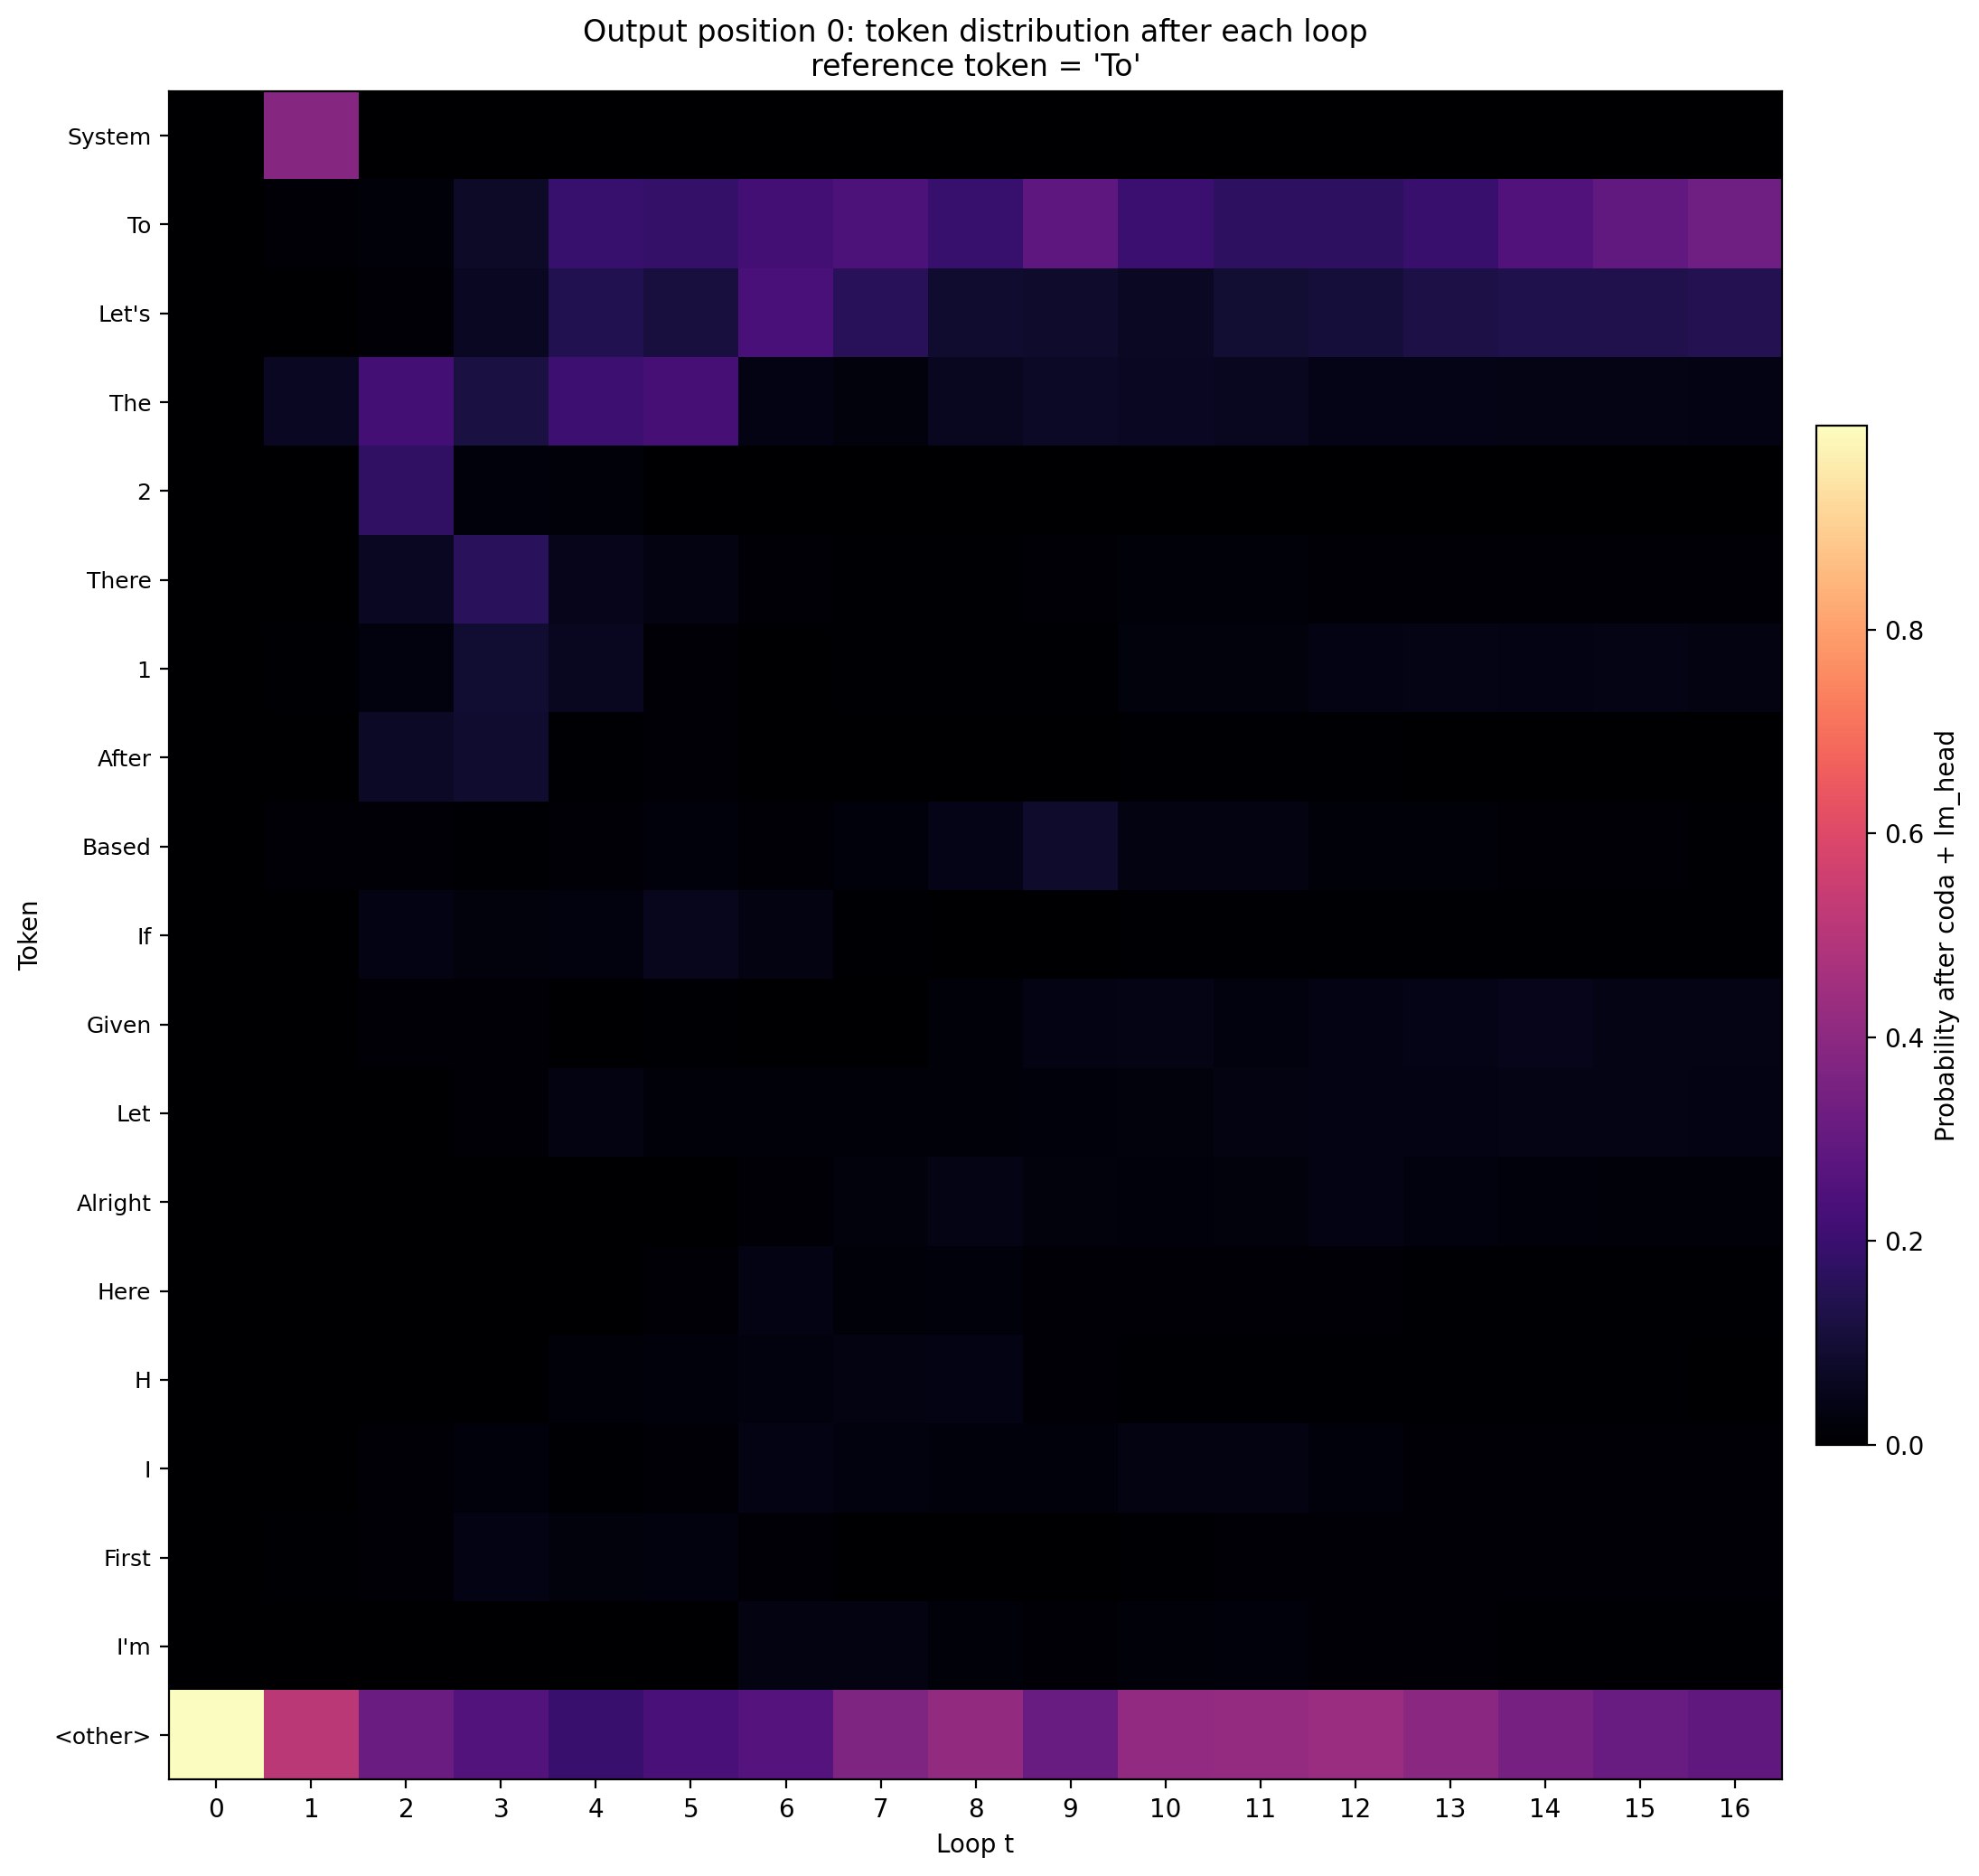

In [5]:
distribution_trace = collect_coda_token_distribution_trace(
    model=model,
    input_ids=target_prefix_ids,
    num_steps=NUM_STEPS,
    init_scale=PREVIEW_INIT_SCALE,
    include_step_zero=True,
    position=-1,
)

selected_token_ids = select_salient_token_ids(
    distribution_trace["probs"],
    top_k_per_step=TOP_K_PER_STEP,
    max_tokens=MAX_TOKENS_TO_SHOW,
    always_include=distribution_trace["argmax_token_ids"],
)

fig, ax = plot_coda_distribution_heatmap(
    distribution_trace,
    tokenizer=tokenizer,
    title=(
        f"Output position {target_output_position}: token distribution after each loop\n"
        f"reference token = {target_reference_label!r}"
    ),
    selected_token_ids=selected_token_ids,
    top_k_per_step=TOP_K_PER_STEP,
    max_tokens=MAX_TOKENS_TO_SHOW,
)
plt.show()


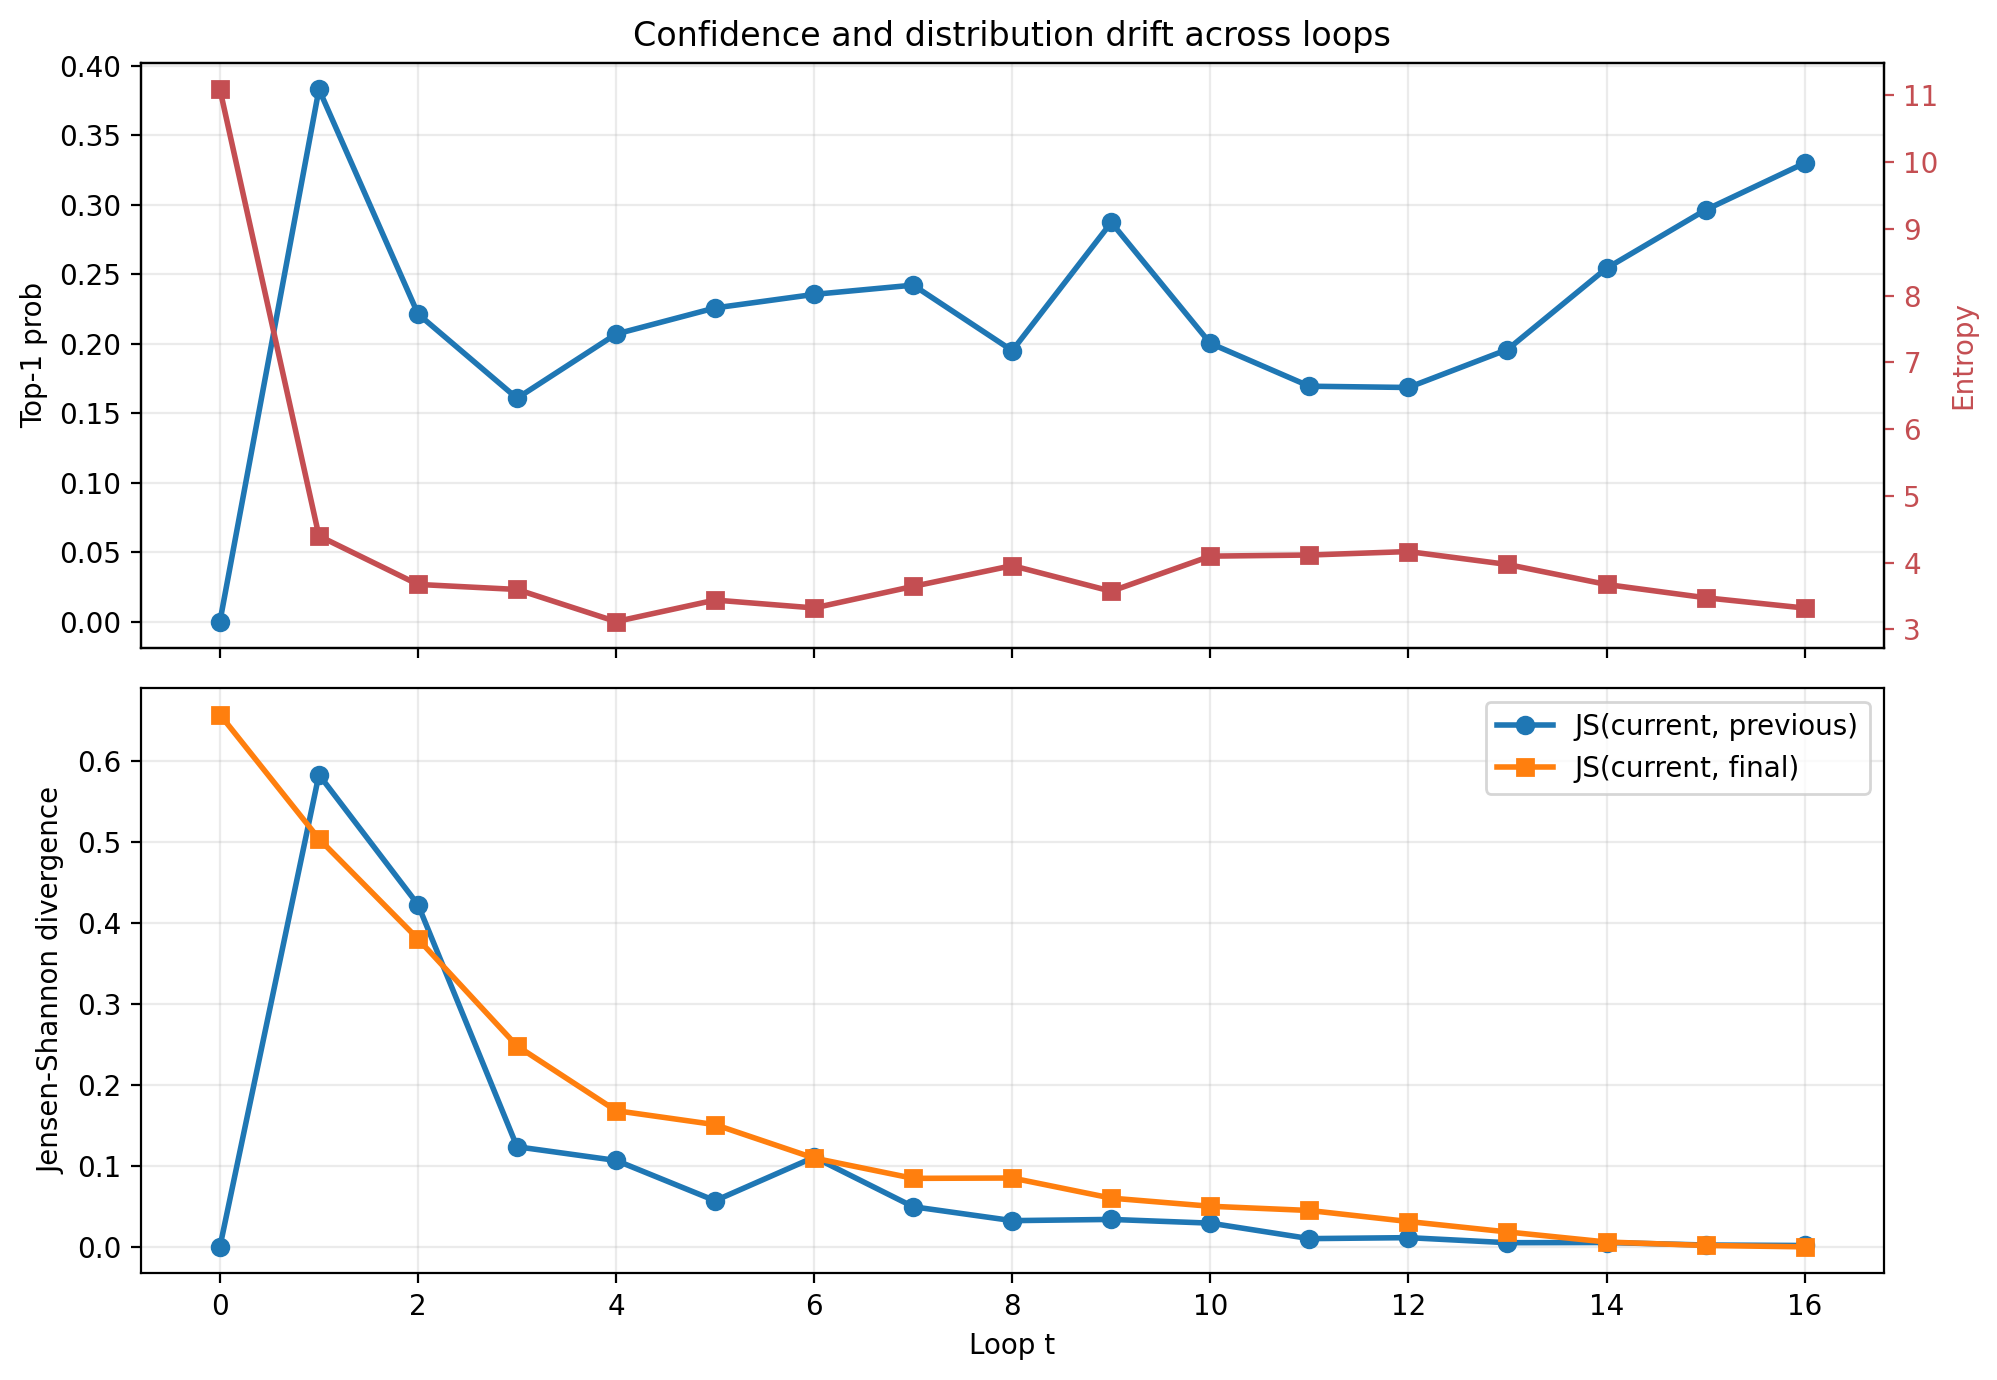

Per-loop top tokens:
loop  0: argmax='\x00' (p=0.000) | :0.000, :0.000, :0.000, :0.000, :0.000,  :0.000, :0.000, :0.000
loop  1: argmax='System' (p=0.383) | System:0.383, The:0.063, -:0.026, A:0.022, Your:0.020, Answer:0.020, In:0.015, An:0.014
loop  2: argmax='The' (p=0.221) | The:0.221, 2:0.172, After:0.072, There:0.063, If:0.038, 1:0.030, In:0.018, To:0.017
loop  3: argmax='There' (p=0.161) | There:0.161, The:0.118, 1:0.092, After:0.086, To:0.076, Let's:0.063, First:0.036, If:0.026
loop  4: argmax='The' (p=0.207) | The:0.207, To:0.194, Let's:0.142, 1:0.059, There:0.049, Let:0.032, If:0.030, First:0.025
loop  5: argmax='The' (p=0.226) | The:0.226, To:0.187, Let's:0.114, If:0.057, There:0.033, First:0.029, Based:0.022, This:0.021
loop  6: argmax="Let's" (p=0.236) | Let's:0.236, To:0.221, Here:0.038, I:0.036, The:0.036, If:0.034, I'm:0.032, H:0.030
loop  7: argmax='To' (p=0.242) | To:0.242, Let's:0.156, I'm:0.035, H:0.035, I:0.029, Okay:0.029, Hello:0.029, Thank:0.027
loop  8: a

In [6]:
steps = distribution_trace["steps"].numpy()

fig, axes = plt.subplots(2, 1, figsize=(10, 7), dpi=200, sharex=True)

axes[0].plot(steps, distribution_trace["argmax_prob"].numpy(), marker="o", linewidth=2)
axes[0].set_ylabel("Top-1 prob")
axes[0].set_title("Confidence and distribution drift across loops")
axes[0].grid(alpha=0.25)

ax_entropy = axes[0].twinx()
ax_entropy.plot(steps, distribution_trace["entropy"].numpy(), color="#C44E52", marker="s", linewidth=2)
ax_entropy.set_ylabel("Entropy", color="#C44E52")
ax_entropy.tick_params(axis="y", colors="#C44E52")

axes[1].plot(steps, distribution_trace["js_delta_from_prev"].numpy(), marker="o", linewidth=2, label="JS(current, previous)")
axes[1].plot(steps, distribution_trace["js_to_final"].numpy(), marker="s", linewidth=2, label="JS(current, final)")
axes[1].set_xlabel("Loop t")
axes[1].set_ylabel("Jensen-Shannon divergence")
axes[1].grid(alpha=0.25)
axes[1].legend()

fig.tight_layout()
plt.show()

argmax_labels = decode_token_ids(tokenizer, distribution_trace["argmax_token_ids"].tolist(), max_chars=24)
topk_probs, topk_ids = torch.topk(distribution_trace["probs"], k=min(TOP_K_TABLE, distribution_trace["probs"].shape[-1]), dim=-1)

print("Per-loop top tokens:")
for step, argmax_label, argmax_prob, ids, probs in zip(
    distribution_trace["steps"].tolist(),
    argmax_labels,
    distribution_trace["argmax_prob"].tolist(),
    topk_ids.tolist(),
    topk_probs.tolist(),
):
    decoded = decode_token_ids(tokenizer, ids, max_chars=20)
    pairs = ", ".join(f"{label}:{prob:.3f}" for label, prob in zip(decoded, probs))
    print(f"loop {step:>2}: argmax={argmax_label!r} (p={argmax_prob:.3f}) | {pairs}")
